In [28]:
import pandas as pd
import random
from datetime import datetime, timedelta

regions = ["North", "South", "East", "West"]

cities = {
    "North": ["Delhi", "Jaipur"],
    "South": ["Hyderabad", "Bangalore", "Chennai", "Visakhapatnam"],
    "East": ["Kolkata", "Bhubaneswar"],
    "West": ["Mumbai", "Pune"]
}

categories = {
    "Electronics": ["Laptop", "Mobile", "Headphones", "Smart Watch"],
    "Clothing": ["T-Shirt", "Jeans", "Jacket", "Shoes"],
    "Grocery": ["Rice", "Oil", "Sugar", "Milk"],
    "Furniture": ["Chair", "Table", "Sofa", "Cupboard"],
    "Sports": ["Cricket Bat", "Football", "Yoga Mat", "Dumbbells"]
}

payments = ["Cash", "Card", "UPI"]
genders = ["Male", "Female"]

start_date = datetime(2025, 1, 1)

data = []

for i in range(1, 501):

    region = random.choice(regions)
    city = random.choice(cities[region])

    category = random.choice(list(categories.keys()))
    product = random.choice(categories[category])

    quantity = random.randint(1, 10)

    unit_price = random.randint(200, 50000)

    discount = random.choice([0, 5, 10, 15, 20, 25, 30])

    gross = quantity * unit_price

    sales = gross * (1 - discount / 100)

    cost = sales * random.uniform(0.60, 0.90)

    profit = sales - cost

    order_date = start_date + timedelta(days=random.randint(0, 364))

    age = random.randint(18, 65)

    gender = random.choice(genders)

    payment = random.choice(payments)

    rating = round(random.uniform(3, 5), 1)

    data.append([
        f"O{i:04}",
        f"C{random.randint(1001,1200)}",
        order_date.strftime("%Y-%m-%d"),
        region,
        city,
        category,
        product,
        quantity,
        unit_price,
        discount,
        round(sales,2),
        round(cost,2),
        round(profit,2),
        payment,
        age,
        gender,
        rating
    ])

columns = [
    "Order_ID",
    "Customer_ID",
    "Order_Date",
    "Region",
    "City",
    "Category",
    "Product",
    "Quantity",
    "Unit_Price",
    "Discount",
    "Sales",
    "Cost",
    "Profit",
    "Payment_Method",
    "Customer_Age",
    "Gender",
    "Rating"
]

df = pd.DataFrame(data, columns=columns)

df.to_csv("Retail_Store_Sales_Dataset_500.csv", index=False)

print("Dataset Created Successfully!")

df.head()

Dataset Created Successfully!


,Order_ID,Customer_ID,Order_Date,Region,City,Category,Product,Quantity,Unit_Price,Discount,Sales,Cost,Profit,Payment_Method,Customer_Age,Gender,Rating
0,O0001,C1160,2025-09-15,North,Delhi,Electronics,Smart Watch,7,14177,25,74429.25,47310.96,27118.29,Card,64,Female,4.1
1,O0002,C1070,2025-12-30,East,Kolkata,Grocery,Sugar,9,12797,30,80621.10,66901.31,13719.79,Card,35,Male,3.1
2,O0003,C1083,2025-05-19,South,Visakhapatnam,Sports,Yoga Mat,10,2897,5,27521.50,20394.03,7127.47,UPI,34,Male,4.4
3,O0004,C1082,2025-07-04,West,Pune,Sports,Cricket Bat,7,28726,5,191027.90,117051.90,73976.00,UPI,47,Male,4.3
4,O0005,C1089,2025-05-19,East,Kolkata,Furniture,Table,10,4326,10,38934.00,33168.55,5765.45,UPI,21,Female,4.8


In [29]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [30]:
df = pd.read_csv("Retail_Store_Sales_Dataset_500.csv")

In [31]:
df.head()

,Order_ID,Customer_ID,Order_Date,Region,City,Category,Product,Quantity,Unit_Price,Discount,Sales,Cost,Profit,Payment_Method,Customer_Age,Gender,Rating
0,O0001,C1160,2025-09-15,North,Delhi,Electronics,Smart Watch,7,14177,25,74429.25,47310.96,27118.29,Card,64,Female,4.1
1,O0002,C1070,2025-12-30,East,Kolkata,Grocery,Sugar,9,12797,30,80621.10,66901.31,13719.79,Card,35,Male,3.1
2,O0003,C1083,2025-05-19,South,Visakhapatnam,Sports,Yoga Mat,10,2897,5,27521.50,20394.03,7127.47,UPI,34,Male,4.4
3,O0004,C1082,2025-07-04,West,Pune,Sports,Cricket Bat,7,28726,5,191027.90,117051.90,73976.00,UPI,47,Male,4.3
4,O0005,C1089,2025-05-19,East,Kolkata,Furniture,Table,10,4326,10,38934.00,33168.55,5765.45,UPI,21,Female,4.8


In [32]:
df.shape

(500, 17)

In [33]:
df.columns

Index(['Order_ID', 'Customer_ID', 'Order_Date', 'Region', 'City', 'Category',
       'Product', 'Quantity', 'Unit_Price', 'Discount', 'Sales', 'Cost',
       'Profit', 'Payment_Method', 'Customer_Age', 'Gender', 'Rating'],
      dtype='object')

In [34]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 17 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Order_ID        500 non-null    object 
 1   Customer_ID     500 non-null    object 
 2   Order_Date      500 non-null    object 
 3   Region          500 non-null    object 
 4   City            500 non-null    object 
 5   Category        500 non-null    object 
 6   Product         500 non-null    object 
 7   Quantity        500 non-null    int64  
 8   Unit_Price      500 non-null    int64  
 9   Discount        500 non-null    int64  
 10  Sales           500 non-null    float64
 11  Cost            500 non-null    float64
 12  Profit          500 non-null    float64
 13  Payment_Method  500 non-null    object 
 14  Customer_Age    500 non-null    int64  
 15  Gender          500 non-null    object 
 16  Rating          500 non-null    float64
dtypes: float64(4), int64(4), object(9)


In [35]:
df.describe()

,Quantity,Unit_Price,Discount,Sales,Cost,Profit,Customer_Age,Rating
count,500.000000,500.000000,500.00000,500.000000,500.000000,500.000000,500.000000,500.000000
mean,5.526000,24691.556000,14.98000,115062.020300,86934.578040,28127.442260,41.868000,4.022800
std,2.811607,14188.026435,10.03998,95553.556885,73881.157052,26200.879859,13.531325,0.566571
min,1.000000,465.000000,0.00000,1759.500000,1068.560000,244.260000,18.000000,3.000000
25%,3.000000,12438.250000,5.00000,36256.712500,27514.767500,8253.720000,31.000000,3.500000
50%,6.000000,24907.000000,15.00000,89958.350000,67748.805000,21021.180000,43.000000,4.100000
75%,8.000000,37209.250000,25.00000,169179.000000,123637.057500,38455.042500,54.000000,4.500000
max,10.000000,49889.000000,30.00000,466330.000000,391049.210000,132316.970000,65.000000,5.000000


In [36]:
df.isnull().sum()

,0
Order_ID,0
Customer_ID,0
Order_Date,0
Region,0
City,0
Category,0
Product,0
Quantity,0
Unit_Price,0
Discount,0


In [37]:
df.duplicated().sum()

np.int64(0)

In [38]:
df.drop_duplicates(inplace=True)

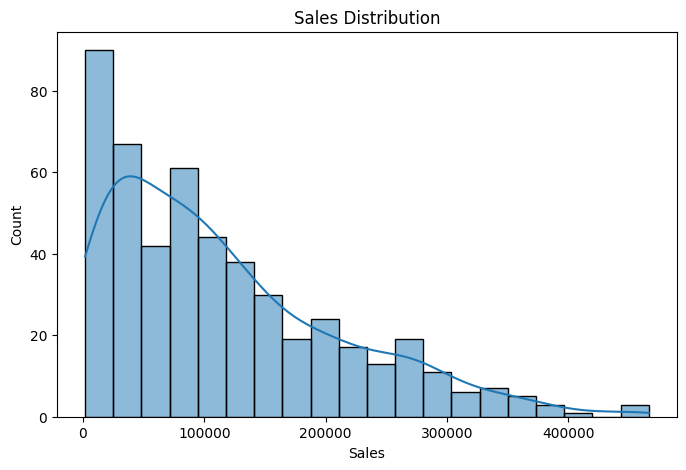

In [39]:
plt.figure(figsize=(8,5))
sns.histplot(df["Sales"], bins=20, kde=True)
plt.title("Sales Distribution")
plt.xlabel("Sales")
plt.ylabel("Count")
plt.show()

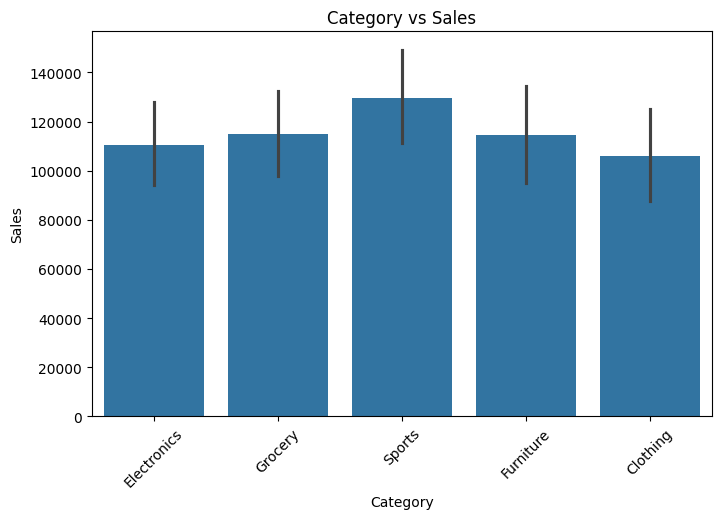

In [40]:
plt.figure(figsize=(8,5))
sns.barplot(x="Category", y="Sales", data=df)
plt.title("Category vs Sales")
plt.xticks(rotation=45)
plt.show()

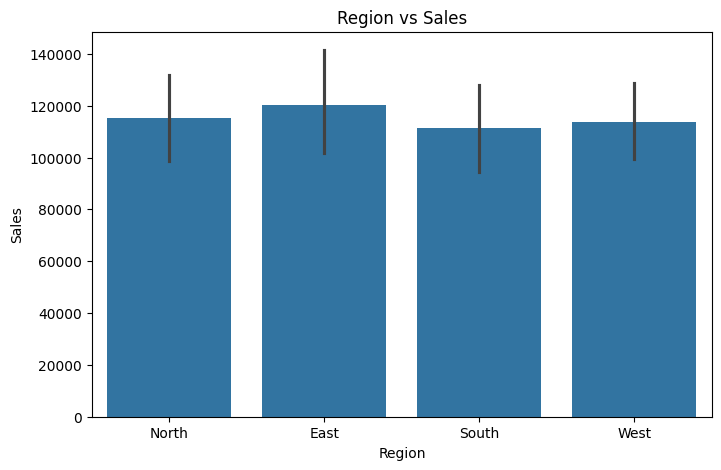

In [41]:
plt.figure(figsize=(8,5))
sns.barplot(x="Region", y="Sales", data=df)
plt.title("Region vs Sales")
plt.show()

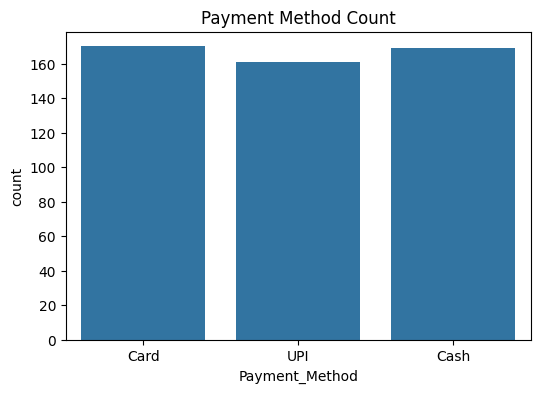

In [42]:
plt.figure(figsize=(6,4))
sns.countplot(x="Payment_Method", data=df)
plt.title("Payment Method Count")
plt.show()

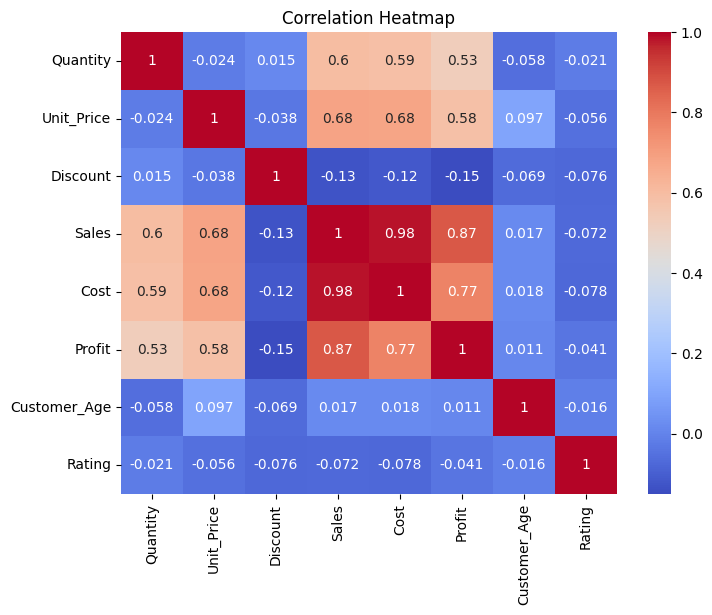

In [43]:
plt.figure(figsize=(8,6))
sns.heatmap(df.corr(numeric_only=True), annot=True, cmap="coolwarm")
plt.title("Correlation Heatmap")
plt.show()

Feature Selection (Selecting Independent and Dependent Variables)

In [44]:
X = df.drop(["Sales", "Order_ID", "Customer_ID"], axis=1)
y = df["Sales"]

In [45]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()

for col in X.select_dtypes(include=['object']).columns:
    X[col] = le.fit_transform(X[col].astype(str))

In [49]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [50]:
from sklearn.ensemble import RandomForestRegressor

model = RandomForestRegressor(random_state=42)
model.fit(X_train, y_train)

RandomForestRegressor(random_state=42)

Sales Prediction

In [52]:
y_pred = model.predict(X_test)

In [53]:
print(X_test.shape)

(100, 14)


In [54]:
y_pred = model.predict(X_test)
print(y_pred[:10])

[ 45818.384  228261.1855 251397.821   25999.361   68579.564  124944.3795
  77466.2265 223444.1555  53374.483  117821.4335]


Model Evaluation

In [55]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)

print("Mean Absolute Error (MAE):", mae)
print("Mean Squared Error (MSE):", mse)
print("Root Mean Squared Error (RMSE):", rmse)
print("R² Score:", r2)

Mean Absolute Error (MAE): 4656.20023500001
Mean Squared Error (MSE): 66595864.18146868
Root Mean Squared Error (RMSE): 8160.62890845238
R² Score: 0.9926659849187531


Actual vs Predicted Sales

In [56]:
results = pd.DataFrame({
    "Actual Sales": y_test.values,
    "Predicted Sales": y_pred
})

results.head(10)

,Actual Sales,Predicted Sales
0,44928.0,45818.3840
1,232254.4,228261.1855
2,236439.0,251397.8210
3,24591.0,25999.3610
4,72859.5,68579.5640
5,135136.4,124944.3795
6,79093.2,77466.2265
7,221930.0,223444.1555
8,51217.6,53374.4830
9,114487.2,117821.4335


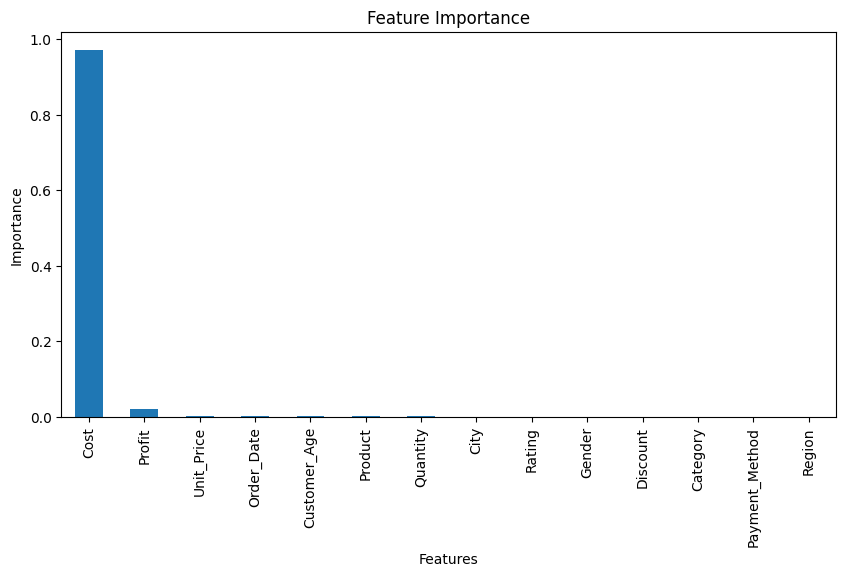

In [57]:
import matplotlib.pyplot as plt
import pandas as pd

feature_importance = pd.Series(model.feature_importances_, index=X.columns)
feature_importance.sort_values(ascending=False).plot(kind='bar', figsize=(10,5))

plt.title("Feature Importance")
plt.xlabel("Features")
plt.ylabel("Importance")
plt.show()